In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
prog = xr.open_mfdataset('prog.nc')

Text(0.5, 1.0, 'T-S at 10 days')

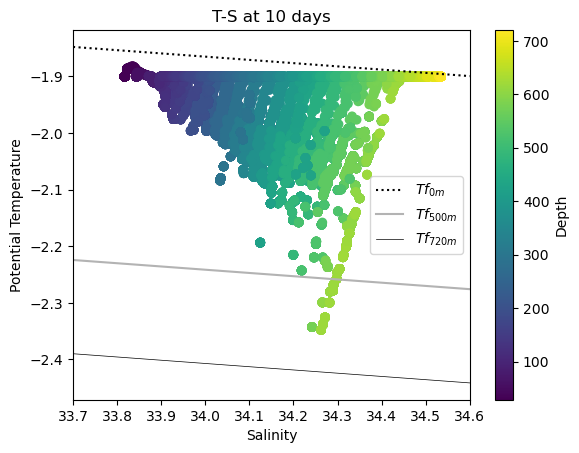

In [19]:
lambda_1=-0.0573
lambda_2=0.0832
lambda_3=-7.53*10**-4
def tf(s0,p):
    return lambda_1*s0 + lambda_2 + lambda_3*p
s0 = np.linspace(33.7,34.6,10)
plt.plot(s0,tf(s0,0), color = 'k', linestyle = ':', label = '$Tf_{0m}$')
plt.plot(s0,tf(s0,500), color = [0.7, 0.7, 0.7], linestyle = '-', label = '$Tf_{500m}$')
plt.plot(s0,tf(s0,720), color = 'k', linestyle = '-', label = '$Tf_{720m}$', linewidth = 0.5)

depth_center = prog.h.cumsum('zl').isel(Time = -1)-prog.e.isel(zi = 0).isel(Time = -1)

plt.scatter(prog.salt.isel(Time = -1),prog.temp.isel(Time = -1),c =depth_center)
plt.colorbar(label = 'Depth')
plt.xlabel('Salinity')
plt.ylabel('Potential Temperature')
plt.xlim(s0[0],s0[-1])
plt.legend()
plt.title('T-S at 10 days')


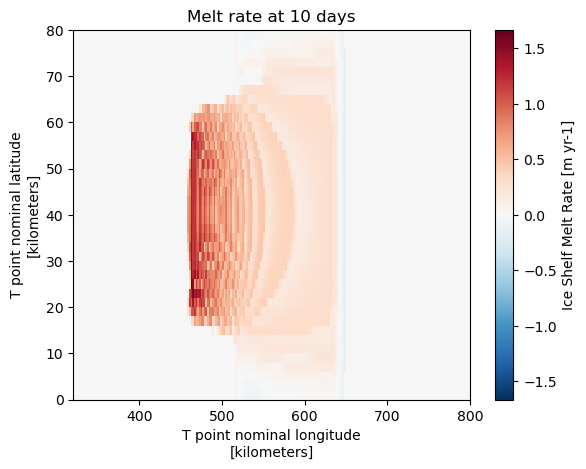

Text(0.5, 1.0, 'Minimum temperature at 10 days')

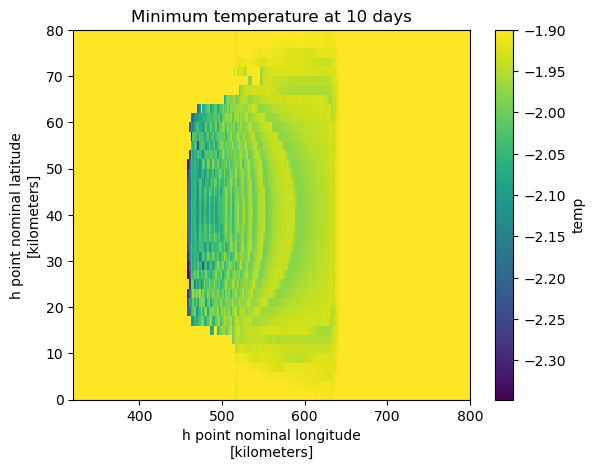

In [18]:
ice = xr.open_dataset('ice.nc')
ice.melt_rate.isel(Time = -1).plot()
plt.title('Melt rate at 10 days')
plt.show()
prog.temp.isel(Time = -1).min('zl').plot()

plt.title('Minimum temperature at 10 days')
